## __Data Science: Capstone Part 1: Lightning Talk 1__

### Overview

In the field of data science, good projects are practical. Your capstone project should be manageable and affect a real world audience. This might be a domain you are familiar with, a particular interest you have, something that affects a community you are involved in, or an area that relates to a field you wish to work in.

One of the best ways to test ideas quickly is to share them with others. A good data scientist has to be comfortable discussing ideas and presenting to audiences. That's why for Part 1 of your Capstone project, you'll be preparing a lightning talk on some potential interest areas and datasets.

This deliverable will provide you with guidance to help you select an awesome topic and begin to build a polished Capstone project.

__Goal__: Host a lightning talk presentation describing at least three project proposals, including associated data, problem statement, goals, approach, and basic EDA.

### REQUIRED

__Foreach Topic__:
- Problem Statement
- Goals
- Approach
- Data Source(s)
- Data Info. (basic EDA)

Dataset should have __15k+__ rows and __10+__ columns

___Remember, if you can't find data to support your topic, then you can't move forward.___

This notebook covers **initial cleaning & inspection** (before full EDA) for the 3 candidate datasets:

| # | Topic | Dataset |
|---|---|---|
| 1 | 🚗 Predicting Vehicle Accident Severity | US Accidents (Kaggle) |
| 2 | 🍎 Food / Nutrition Classification | Global Food & Nutrition Database 2026 (Kaggle) |
| 3 | 📱 Customer Churn Prediction | Customer Churn Prediction Dataset 1M (Kaggle) |


---
# 🚗 Topic 1: Predicting Vehicle Accident Severity

**File:** `US_Accidents.csv` &nbsp;|&nbsp; **Target column (placeholder):** `Severity`



### 📋 Topic 1 — Required Write-up

**Problem Statement**
Traffic accidents in the US vary widely in severity, from minor delays to fatal multi-car incidents. Emergency responders, insurers, and city planners need a reliable way to anticipate how severe an accident is likely to be given the conditions it occurs under.

**Goals**
Build a classification model that predicts accident `Severity` (1-4) from road, weather, time-of-day, and location features, and identify which factors are most associated with higher-severity accidents.

**Approach**
1. Clean and inspect the raw accident records (this notebook).
2. Engineer features from `Start_Time`/`End_Time` (hour, day of week, duration) and weather columns.
3. Train baseline (Logistic Regression) and tree-based models (Random Forest / XGBoost) on the multi-class target.
4. Evaluate with macro F1 / confusion matrix, since `Severity` classes are imbalanced.

**Data Source(s)**
US Accidents (Kaggle) - nationwide car accident dataset covering 49 US states, ~7.7M rows and 46 columns (location, time, weather, and road-feature attributes).

**Data Info (basic EDA)**
See sections 1-13 below for shape, dtypes, missingness, duplicates, outliers, and target distribution.


## 1. Load Data & Raw Shape

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# NOTE: update filename/path to match your downloaded file
df1 = pd.read_csv("./data/US_Accidents.csv")
print("Rows and Columns (before cleaning):", df1.shape)

rows_before_1 = df1.shape[0]  # captured for the summary checklist below


Rows and Columns (before cleaning): (7728394, 46)


In [11]:
df1.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


### 📖 Data Dictionary — Topic 1 (US Accidents)

| Column | Type | Description |
|---|---|---|
| `ID` | string | Unique identifier for the accident record |
| `Severity` | int (1-4) | **Target.** Impact on traffic (1 = least, 4 = most severe) |
| `Start_Time` / `End_Time` | datetime | When the accident began / traffic impact cleared |
| `Start_Lat` / `Start_Lng` | float | GPS coordinates of the accident |
| `Distance(mi)` | float | Length of road affected by the accident |
| `Description` | string | Free-text human-written description of the accident |
| `Street` / `City` / `County` / `State` / `Zipcode` | string | Location fields |
| `Temperature(F)`, `Humidity(%)`, `Pressure(in)`, `Visibility(mi)` | float | Weather conditions at the time |
| `Wind_Direction`, `Wind_Speed(mph)`, `Precipitation(in)`, `Weather_Condition` | mixed | Additional weather conditions |
| `Amenity`, `Bump`, `Crossing`, `Give_Way`, `Junction`, `No_Exit`, `Railway`, `Roundabout`, `Station`, `Stop`, `Traffic_Calming`, `Traffic_Signal` | bool | Nearby road features (POIs) |
| `Sunrise_Sunset` | string | Whether it was day or night |

*Confirm exact column names against the file once downloaded — Kaggle versions vary slightly.*


## 2. Data Types

In [12]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     str    
 1   Source                 str    
 2   Severity               int64  
 3   Start_Time             str    
 4   End_Time               str    
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            str    
 11  Street                 str    
 12  City                   str    
 13  County                 str    
 14  State                  str    
 15  Zipcode                str    
 16  Country                str    
 17  Timezone               str    
 18  Airport_Code           str    
 19  Weather_Timestamp      str    
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)            float6

## 3. Descriptive Statistics (`describe()`)
Numerical summary first, then categorical summary.

In [13]:
# Numerical columns summary
df1.describe()

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,7.728394e+06,7.728394e+06,7.728394e+06,4.325632e+06,4.325632e+06,7.728394e+06,7.564541e+06,5.729375e+06,7.554250e+06,7.587715e+06,7.551296e+06,7.157161e+06,5.524808e+06
mean,2.212384e+00,3.620119e+01,-9.470255e+01,3.626183e+01,-9.572557e+01,5.618423e-01,6.166329e+01,5.825105e+01,6.483104e+01,2.953899e+01,9.090376e+00,7.685490e+00,8.407210e-03
std,4.875313e-01,5.076079e+00,1.739176e+01,5.272905e+00,1.810793e+01,1.776811e+00,1.901365e+01,2.238983e+01,2.282097e+01,1.006190e+00,2.688316e+00,5.424983e+00,1.102246e-01
min,1.000000e+00,2.455480e+01,-1.246238e+02,2.456601e+01,-1.245457e+02,0.000000e+00,-8.900000e+01,-8.900000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,3.339963e+01,-1.172194e+02,3.346207e+01,-1.177543e+02,0.000000e+00,4.900000e+01,4.300000e+01,4.800000e+01,2.937000e+01,1.000000e+01,4.600000e+00,0.000000e+00
50%,2.000000e+00,3.582397e+01,-8.776662e+01,3.618349e+01,-8.802789e+01,3.000000e-02,6.400000e+01,6.200000e+01,6.700000e+01,2.986000e+01,1.000000e+01,7.000000e+00,0.000000e+00
75%,2.000000e+00,4.008496e+01,-8.035368e+01,4.017892e+01,-8.024709e+01,4.640000e-01,7.600000e+01,7.500000e+01,8.400000e+01,3.003000e+01,1.000000e+01,1.040000e+01,0.000000e+00
max,4.000000e+00,4.900220e+01,-6.711317e+01,4.907500e+01,-6.710924e+01,4.417500e+02,2.070000e+02,2.070000e+02,1.000000e+02,5.863000e+01,1.400000e+02,1.087000e+03,3.647000e+01


In [14]:
# Categorical / object columns summary
df1.describe(include='str')

,ID,Source,Start_Time,End_Time,Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Wind_Direction,Weather_Condition,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
count,7728394,7728394,7728394,7728394,7728389,7717525,7728141,7728394,7728394,7726479,7728394,7720586,7705759,7608166,7553188,7554935,7705148,7705148,7705148,7705148
unique,7728394,3,6131796,6705355,3761578,336306,13678,1871,49,825094,1,4,2045,941331,24,144,2,2,2,2
top,A-1,Source1,2021-01-26 16:16:13,2021-11-22 08:00:00,A crash has occurred causing no to minimum del...,I-95 N,Miami,Los Angeles,CA,91761,US,US/Eastern,KCQT,2022-03-13 01:53:00,CALM,Fair,Day,Day,Day,Day
freq,1,4325632,225,112,9593,78430,186917,526851,1741433,11247,7728394,3580167,118332,1311,961624,2560802,5334553,5695619,6076156,6377548


## 4. Missing Values

In [15]:
missing = df1.isnull().sum()
missing_percentage = (missing / len(df1)) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percentage
})

missing_table.sort_values(by="Missing Values", ascending=False).head(20)

,Missing Values,Percentage
End_Lng,3402762,44.029355
End_Lat,3402762,44.029355
Precipitation(in),2203586,28.512858
Wind_Chill(F),1999019,25.865904
Wind_Speed(mph),571233,7.391355
Visibility(mi),177098,2.291524
Wind_Direction,175206,2.267043
Humidity(%),174144,2.253301
Weather_Condition,173459,2.244438
Temperature(F),163853,2.120143


**Plan for missing values** *(fill in after seeing real output)*:
- High missing % (e.g. >40-50%) → consider dropping the column
- Low missing % → impute (median for numeric / mode for categorical) or drop rows
- Document reasoning per column here once known.

## 5. Duplicate Rows

In [16]:
dup_count_1 = df1.duplicated().sum()
print("Duplicate rows:", dup_count_1)

Duplicate rows: 0


In [17]:
df1 = df1.drop_duplicates()
print("Shape after removing duplicates:", df1.shape)

Shape after removing duplicates: (7728394, 46)


## 6. Column Integrity Check
Confirm no columns were lost unintentionally.

In [18]:
original_columns_1 = df1.columns
print("Original column count:", len(original_columns_1))

Original column count: 46


In [19]:
print("Current column count:", len(df1.columns))

Current column count: 46


## 7. Sentinel / Placeholder Missing Values
Some datasets hide missing data behind values like `-1`, `0` (when it shouldn't be), `'Unknown'`, `'N/A'`, `'?'`, or empty strings — these won't show up in `isnull()`. Worth checking before EDA.

In [20]:
# Check for common placeholder strings in object columns
placeholder_values = ['?', 'Unknown', 'unknown', 'N/A', 'n/a', 'NA', '', ' ', 'None', 'null']

placeholder_summary_1 = {}
for col in df1.select_dtypes(include='str').columns:
    found = df1[col].isin(placeholder_values).sum()
    if found > 0:
        placeholder_summary_1[col] = int(found)
        print(f"{col}: {found} placeholder-like values")

if not placeholder_summary_1:
    print("No placeholder-style missing values found.")


Description: 34 placeholder-like values


## 8. Outlier Detection (IQR Method)
Flags numeric columns with potential outliers using the 1.5×IQR rule.

In [21]:
numeric_cols_1 = df1.select_dtypes(include=np.number).columns
outlier_summary = {}

for col in numeric_cols_1:
    Q1 = df1[col].quantile(0.25)
    Q3 = df1[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df1[col] < lower) | (df1[col] > upper)).sum()
    if n_outliers > 0:
        outlier_summary[col] = n_outliers

pd.DataFrame.from_dict(outlier_summary, orient='index', columns=['Outlier Count']).sort_values('Outlier Count', ascending=False)

,Outlier Count
Severity,1571413
Visibility(mi),1481065
Distance(mi),963606
Precipitation(in),533090
Pressure(in),443383
Wind_Speed(mph),210603
Temperature(F),50515
Wind_Chill(F),43869


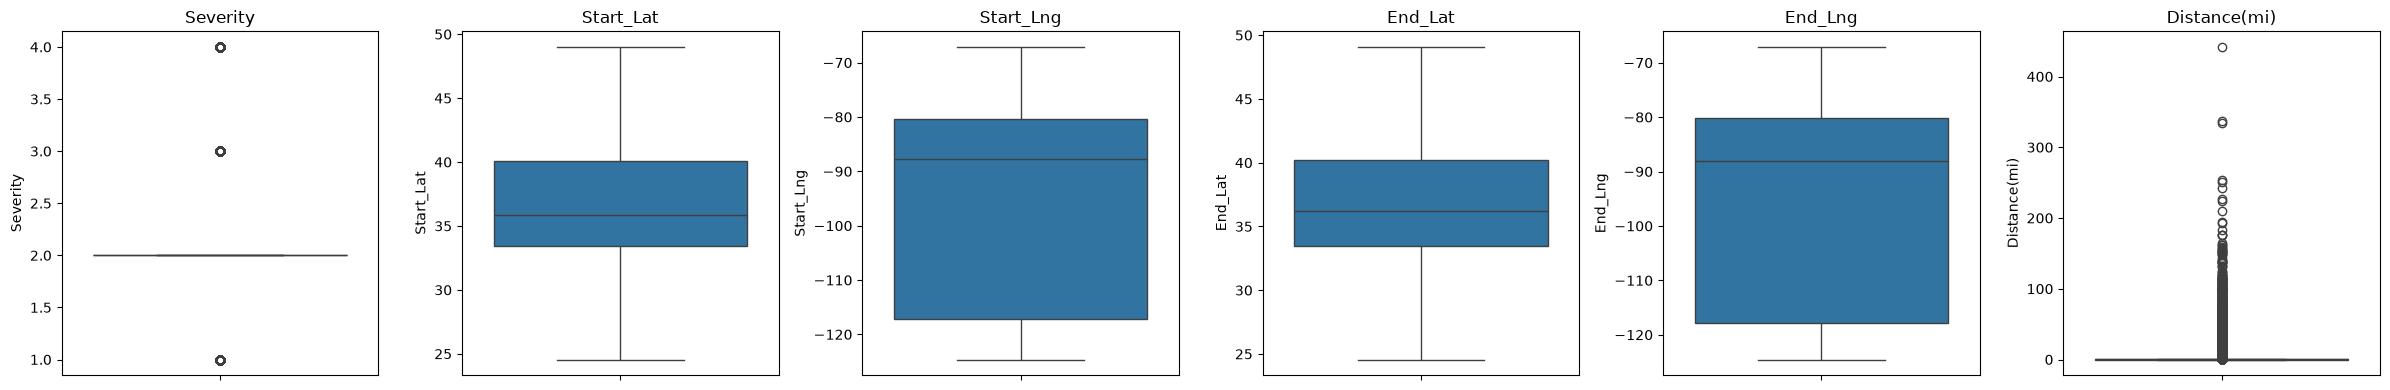

In [22]:
# Boxplots for a quick visual check (adjust column list once you know your real numeric columns)
cols_to_plot = list(numeric_cols_1)[:6]  # first 6 numeric columns as a sample
if cols_to_plot:
    fig, axes = plt.subplots(1, len(cols_to_plot), figsize=(4*len(cols_to_plot), 4))
    if len(cols_to_plot) == 1:
        axes = [axes]
    for ax, col in zip(axes, cols_to_plot):
        sns.boxplot(y=df1[col], ax=ax)
        ax.set_title(col)
    plt.tight_layout()
    plt.show()

## 9. Categorical Cardinality Check
How many unique values does each categorical column have? High-cardinality columns (e.g. IDs, free text) may need special handling or dropping.

In [23]:
categorical_cols_1 = df1.select_dtypes(include='str').columns
cardinality = df1[categorical_cols_1].nunique().sort_values(ascending=False)
cardinality

ID                       7728394
End_Time                 6705355
Start_Time               6131796
Description              3761578
Weather_Timestamp         941331
Zipcode                   825094
Street                    336306
City                       13678
Airport_Code                2045
County                      1871
Weather_Condition            144
State                         49
Wind_Direction                24
Timezone                       4
Source                         3
Sunrise_Sunset                 2
Nautical_Twilight              2
Civil_Twilight                 2
Astronomical_Twilight          2
Country                        1
dtype: int64

## 10. Target Column Check — `Severity`
`Severity` is ordinal/discrete (typically 1-4) → this is a **classification** problem.

In [24]:
target_col_1 = "Severity"  # <-- update to the real column name once confirmed

df1[target_col_1].value_counts()

Severity
2    6156981
3    1299337
4     204710
1      67366
Name: count, dtype: int64

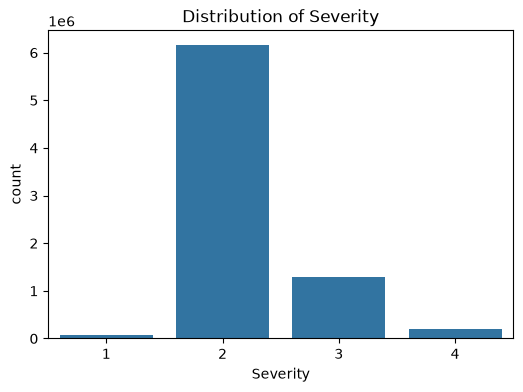

In [25]:
plt.figure(figsize=(6,4))
if df1[target_col_1].dtype == 'str' or df1[target_col_1].nunique() < 20:
    sns.countplot(x=target_col_1, data=df1)
else:
    sns.histplot(df1[target_col_1], kde=True)
plt.title(f"Distribution of {target_col_1}")
plt.show()

## 11. Numerical vs Categorical Column Counts

In [26]:
numeric_cols_1 = df1.select_dtypes(include=np.number).columns
categorical_cols_1 = df1.select_dtypes(include='str').columns

print("Numerical columns:", len(numeric_cols_1))
print("Categorical columns:", len(categorical_cols_1))

print("\nNumerical:", list(numeric_cols_1))
print("\nCategorical:", list(categorical_cols_1))

Numerical columns: 13
Categorical columns: 20

Numerical: ['Severity', 'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)']

Categorical: ['ID', 'Source', 'Start_Time', 'End_Time', 'Description', 'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Wind_Direction', 'Weather_Condition', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']


## 12. Memory Usage

In [27]:
df1.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     str    
 1   Source                 str    
 2   Severity               int64  
 3   Start_Time             str    
 4   End_Time               str    
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            str    
 11  Street                 str    
 12  City                   str    
 13  County                 str    
 14  State                  str    
 15  Zipcode                str    
 16  Country                str    
 17  Timezone               str    
 18  Airport_Code           str    
 19  Weather_Timestamp      str    
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)            float6

## 🧹 Additional Cleaning — Topic 1

In [28]:
# Convert time columns to real datetimes and engineer a duration feature
df1['Start_Time'] = pd.to_datetime(df1['Start_Time'], errors='coerce')
df1['End_Time'] = pd.to_datetime(df1['End_Time'], errors='coerce')
df1['Duration_min'] = (df1['End_Time'] - df1['Start_Time']).dt.total_seconds() / 60

# Drop rows where duration is negative or absurdly long (likely bad data)
df1 = df1[(df1['Duration_min'] >= 0) & (df1['Duration_min'] < 24*60)]
print(df1['Duration_min'].describe())

count    6.956255e+06
mean     1.059277e+02
std      1.232715e+02
min      1.216667e+00
25%      3.000000e+01
50%      6.215000e+01
75%      1.221167e+02
max      1.439983e+03
Name: Duration_min, dtype: float64


In [29]:
# Standardize column names: strip stray whitespace
df1.columns = [c.strip() for c in df1.columns]
print(df1.columns.tolist()[:10], '...')

['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)'] ...


In [30]:
# Drop columns that are missing more than 40% of their values
missing_pct = df1.isnull().mean().sort_values(ascending=False)
cols_to_drop = missing_pct[missing_pct > 0.40].index.tolist()
print("Dropping high-missing columns:", cols_to_drop)
df1 = df1.drop(columns=cols_to_drop)

Dropping high-missing columns: ['End_Lat', 'End_Lng']


In [31]:
# Impute remaining missing numeric weather values with the median,
# and missing categorical weather/road values with the mode
num_cols_1 = df1.select_dtypes(include=np.number).columns
cat_cols_1 = df1.select_dtypes(include='str').columns

for c in num_cols_1:
    if df1[c].isnull().any():
        df1[c] = df1[c].fillna(df1[c].median())

for c in cat_cols_1:
    if df1[c].isnull().any():
        df1[c] = df1[c].fillna(df1[c].mode().iloc[0])

print("Remaining missing values:", df1.isnull().sum().sum())

Remaining missing values: 0


In [32]:
# Cap outliers in Distance(mi) using the IQR method instead of just flagging them
q1, q3 = df1['Distance(mi)'].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
before = df1['Distance(mi)'].copy()
df1['Distance(mi)'] = df1['Distance(mi)'].clip(lower=max(lower, 0), upper=upper)
print(f"Capped Distance(mi) to [{max(lower,0):.2f}, {upper:.2f}] - values changed: {(before != df1['Distance(mi)']).sum()}")

Capped Distance(mi) to [0.00, 0.96] - values changed: 943836


## 13. Summary Checklist — Topic 1

Run the cell below to auto-generate the checklist from the cleaned `df1`.

In [ ]:

missing_final_1 = df1.isnull().sum()
top_missing_1 = missing_final_1[missing_final_1 > 0].sort_values(ascending=False).head(5)
numeric_cols_final_1 = df1.select_dtypes(include=np.number).columns
categorical_cols_final_1 = df1.select_dtypes(include='str').columns
cardinality_final_1 = df1[categorical_cols_final_1].nunique().sort_values(ascending=False)
high_card_1 = cardinality_final_1[cardinality_final_1 > 50].index.tolist()

meets_req_1 = "✅ Yes" if (df1.shape[0] >= 15000 and df1.shape[1] >= 10) else "❌ No"
placeholder_txt_1 = ", ".join(f"{k} ({v})" for k, v in placeholder_summary_1.items()) if placeholder_summary_1 else "None found"
top_missing_txt_1 = ", ".join(top_missing_1.index.tolist()) if len(top_missing_1) else "None"
high_card_txt_1 = ", ".join(high_card_1) if high_card_1 else "None"

| Check | Result |
|---|---|
| Rows before cleaning | {rows_before_1:,} |
| Rows after removing duplicates | {df1.shape[0]:,} |
| Columns | {df1.shape[1]} |
| Meets 15k+ rows / 10+ columns requirement? | {meets_req_1} |
| Duplicate rows found | {dup_count_1:,} |
| Placeholder/sentinel missing values found? | {placeholder_txt_1} |
| Columns with most missing values | {top_missing_txt_1} |
| Numerical columns | {len(numeric_cols_final_1)} |
| Categorical columns | {len(categorical_cols_final_1)} |
| High-cardinality categorical columns (>50 unique) | {high_card_txt_1} |


---
# 🍎 Topic 2: Food / Nutrition Classification

**File:** `Global_Food_Nutrition_2026.csv` &nbsp;|&nbsp; **Target column (placeholder):** `Category`

⚠️ This dataset is the most likely to be borderline on the 'no NLP/text datasets' rule — inspect column types closely in section 2 before committing to it.

### 📋 Topic 2 — Required Write-up

**Problem Statement**
Nutrition and health-scoring apps need a way to automatically classify food items and flag their healthiness from raw nutrition-label data, which is often incomplete or inconsistently entered.

**Goals**
Build a classification model that predicts a food's `food_category` (or `food_type`) from its nutrition facts (calories, macros, micronutrients), supporting automatic tagging of new food entries.

**Approach**
1. Clean and inspect the raw nutrition data (this notebook), paying attention to free-text fields (`ingredients`, `food_name`).
2. Impute or drop missing nutrition values, normalize text categories.
3. Train a multi-class classifier (Random Forest / XGBoost / LightGBM) on numeric nutrition features.
4. Evaluate with macro F1 across categories, checking for class imbalance.

**Data Source(s)**
Global Food & Nutrition Database 2026 (Kaggle) - 40,000 food items with nutrition facts (calories, carbs, fat, protein, vitamins, minerals) and category/brand metadata.

**Data Info (basic EDA)**
See sections 1-13 below for shape, dtypes, missingness, duplicates, outliers, and target distribution.

⚠️ Note: the placeholder target above was listed as `Category`, but the real column name in this dataset is **`food_category`** - update `target_col_3` accordingly before modeling (see the fix in Section 14 below).


## 1. Load Data & Raw Shape

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# NOTE: update filename/path to match your downloaded file
df3 = pd.read_csv("./data/comprehensive_foods_usda.csv")

print("Rows and Columns (before cleaning):", df3.shape)

rows_before_3 = df3.shape[0]  # captured for the summary checklist below


Rows and Columns (before cleaning): (40000, 24)


In [35]:
df3.head()

,fdc_id,food_name,data_type,food_category,brand_owner,brand_name,ingredients,serving_size,serving_unit,household_serving,...,protein_g,saturated_fat_g,vitamin_c_mg,fiber_g,iron_mg,sodium_mg,sugar_g,cholesterol_mg,health_score,food_type
0,167782,"Abiyuch, raw",SR Legacy,Fruits and Fruit Juices,NaN,NaN,NaN,NaN,NaN,NaN,...,1.50,0.014,54.1,5.3,1.61,20.0,8.55,NaN,65,Fruits
1,171687,"Acerola juice, raw",SR Legacy,Fruits and Fruit Juices,NaN,NaN,NaN,NaN,NaN,NaN,...,0.40,0.068,1600.0,0.3,0.50,3.0,4.50,0.0,55,Fruits
2,171686,"Acerola, (west indian cherry), raw",SR Legacy,Fruits and Fruit Juices,NaN,NaN,NaN,NaN,NaN,NaN,...,0.40,0.068,1680.0,1.1,0.20,7.0,NaN,0.0,55,Fruits
3,168061,Acorn stew (Apache),SR Legacy,American Indian/Alaska Native Foods,NaN,NaN,NaN,NaN,NaN,NaN,...,6.81,1.280,0.0,0.7,1.00,130.0,0.34,20.0,50,Other
4,168992,"Agave, cooked (Southwest)",SR Legacy,American Indian/Alaska Native Foods,NaN,NaN,NaN,NaN,NaN,NaN,...,0.99,NaN,0.3,10.6,3.55,13.0,20.90,0.0,50,Other


### 📖 Data Dictionary — Topic 2 (Food / Nutrition, `df3`)

| Column | Type | Description |
|---|---|---|
| `food_name` | string | Name of the food item |
| `food_category` | string | **Target.** Category/classification of the food |
| `brand_owner` / `brand_name` | string | Manufacturer / brand information |
| `ingredients` | string (free text) | Ingredient list — ⚠️ watch for this pushing the dataset toward "NLP/text" territory |
| `serving_size` / `serving_unit` / `household_serving` | mixed | Serving-size information |
| `calories` | float | Energy per serving (kcal) |
| `protein_g`, `fat_g`, `saturated_fat_g`, `carbs_g`, `fiber_g`, `sugar_g` | float | Macronutrients (grams) |
| `sodium_mg`, `cholesterol_mg`, `calcium_mg`, `iron_mg`, `vitamin_c_mg` | float | Micronutrients (mg) |
| `food_type` | string | Broad food type/grouping |

*Note: internal variable name for this dataframe stays `df3` (matches its original position as Topic 3), even though it's now the notebook's 2nd topic.*


## 2. Columns & Data Types

In [36]:
df3.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fdc_id             40000 non-null  int64  
 1   food_name          40000 non-null  str    
 2   data_type          40000 non-null  str    
 3   food_category      39954 non-null  str    
 4   brand_owner        31383 non-null  str    
 5   brand_name         30254 non-null  str    
 6   ingredients        31656 non-null  str    
 7   serving_size       31842 non-null  float64
 8   serving_unit       31842 non-null  str    
 9   household_serving  30790 non-null  str    
 10  calories           39538 non-null  float64
 11  carbs_g            39411 non-null  float64
 12  calcium_mg         34215 non-null  float64
 13  fat_g              39713 non-null  float64
 14  protein_g          39747 non-null  float64
 15  saturated_fat_g    35014 non-null  float64
 16  vitamin_c_mg       22940 non-null

## 3. Descriptive Statistics (`describe()`)
Numerical summary first, then categorical summary.

In [37]:
# Numerical columns summary
df3.describe()

,fdc_id,serving_size,calories,carbs_g,calcium_mg,fat_g,protein_g,saturated_fat_g,vitamin_c_mg,fiber_g,iron_mg,sodium_mg,sugar_g,cholesterol_mg,health_score
count,4.000000e+04,31842.000000,39538.000000,39411.000000,34215.000000,39713.000000,39747.000000,35014.000000,22940.000000,33725.000000,34250.000000,3.938300e+04,35739.000000,34158.000000,40000.000000
mean,1.793461e+06,92.563962,308.159861,28.420500,106.091172,12.118343,8.260691,4.451546,24.138259,2.568491,2.389289,1.067233e+03,13.262690,62.575833,48.887250
std,8.964022e+05,100.581765,392.575965,47.614576,1327.632746,19.140351,10.668951,7.387522,1419.157682,5.662308,60.647733,2.895701e+04,36.323827,2141.337343,9.850912
min,1.675120e+05,0.000000,0.000000,-0.705000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,20.000000
25%,1.459896e+06,28.000000,85.000000,3.570000,5.000000,0.000000,0.420000,0.000000,0.000000,0.000000,0.030000,1.600000e+01,0.000000,0.000000,40.000000
50%,2.094756e+06,55.000000,250.000000,15.600000,29.000000,4.550000,5.130000,1.670000,0.000000,1.000000,0.980000,1.430000e+02,4.520000,0.000000,50.000000
75%,2.469605e+06,118.000000,404.000000,51.800000,98.000000,17.600000,12.500000,6.077500,5.200000,3.300000,2.280000,4.810000e+02,16.700000,38.000000,55.000000
max,2.752382e+06,5055.000000,37600.000000,6160.000000,150000.000000,1170.000000,760.000000,300.000000,210000.000000,588.000000,8930.000000,4.690000e+06,5560.000000,214000.000000,75.000000


In [38]:
# Categorical / object columns summary
df3.describe(include='str')

,food_name,data_type,food_category,brand_owner,brand_name,ingredients,serving_unit,household_serving,food_type
count,40000,40000,39954,31383,30254,31656,31842,30790,40000
unique,30900,3,240,5559,7174,24696,8,4226,9
top,2% REDUCED FAT MILK,Branded,"Fruit & Vegetable Juice, Nectars & Fruit Drinks",Beaver Street Fisheries Inc.,AHOLD,"REDUCED FAT MILK, VITAMIN A PALMITATE, VITAMIN...",g,1 Tbsp,Other
freq,386,31842,1937,706,421,153,18531,1881,15521


## 4. Missing Values

In [39]:
missing = df3.isnull().sum()
missing_percentage = (missing / len(df3)) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percentage
})

missing_table.sort_values(by="Missing Values", ascending=False).head(20)

,Missing Values,Percentage
vitamin_c_mg,17060,42.6500
brand_name,9746,24.3650
household_serving,9210,23.0250
brand_owner,8617,21.5425
ingredients,8344,20.8600
serving_unit,8158,20.3950
serving_size,8158,20.3950
fiber_g,6275,15.6875
cholesterol_mg,5842,14.6050
calcium_mg,5785,14.4625


**Plan for missing values** *(fill in after seeing real output)*:
- High missing % (e.g. >40-50%) → consider dropping the column
- Low missing % → impute (median for numeric / mode for categorical) or drop rows
- Document reasoning per column here once known.

## 5. Duplicate Rows

In [40]:
dup_count_3 = df3.duplicated().sum()
print("Duplicate rows:", dup_count_3)

Duplicate rows: 0


In [41]:
df3 = df3.drop_duplicates()
print("Shape after removing duplicates:", df3.shape)

Shape after removing duplicates: (40000, 24)


## 6. Column Integrity Check
Confirm no columns were lost unintentionally.

In [42]:
original_columns_3 = df3.columns
print("Original column count:", len(original_columns_3))

Original column count: 24


In [43]:
print("Current column count:", len(df3.columns))

Current column count: 24


## 7. Sentinel / Placeholder Missing Values
Some datasets hide missing data behind values like `-1`, `0` (when it shouldn't be), `'Unknown'`, `'N/A'`, `'?'`, or empty strings — these won't show up in `isnull()`. Worth checking before EDA.

In [44]:
# Check for common placeholder strings in object columns
placeholder_values = ['?', 'Unknown', 'unknown', 'N/A', 'n/a', 'NA', '', ' ', 'None', 'null']

placeholder_summary_3 = {}
for col in df3.select_dtypes(include='str').columns:
    found = df3[col].isin(placeholder_values).sum()
    if found > 0:
        placeholder_summary_3[col] = int(found)
        print(f"{col}: {found} placeholder-like values")

if not placeholder_summary_3:
    print("No placeholder-style missing values found.")


No placeholder-style missing values found.


## 8. Outlier Detection (IQR Method)
Flags numeric columns with potential outliers using the 1.5×IQR rule.

In [45]:
numeric_cols_3 = df3.select_dtypes(include=np.number).columns
outlier_summary = {}

for col in numeric_cols_3:
    Q1 = df3[col].quantile(0.25)
    Q3 = df3[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df3[col] < lower) | (df3[col] > upper)).sum()
    if n_outliers > 0:
        outlier_summary[col] = n_outliers

pd.DataFrame.from_dict(outlier_summary, orient='index', columns=['Outlier Count']).sort_values('Outlier Count', ascending=False)

,Outlier Count
vitamin_c_mg,3953
sugar_g,3575
saturated_fat_g,2560
fiber_g,2536
calcium_mg,2482
sodium_mg,2424
fat_g,2017
cholesterol_mg,1806
calories,1536
iron_mg,1475


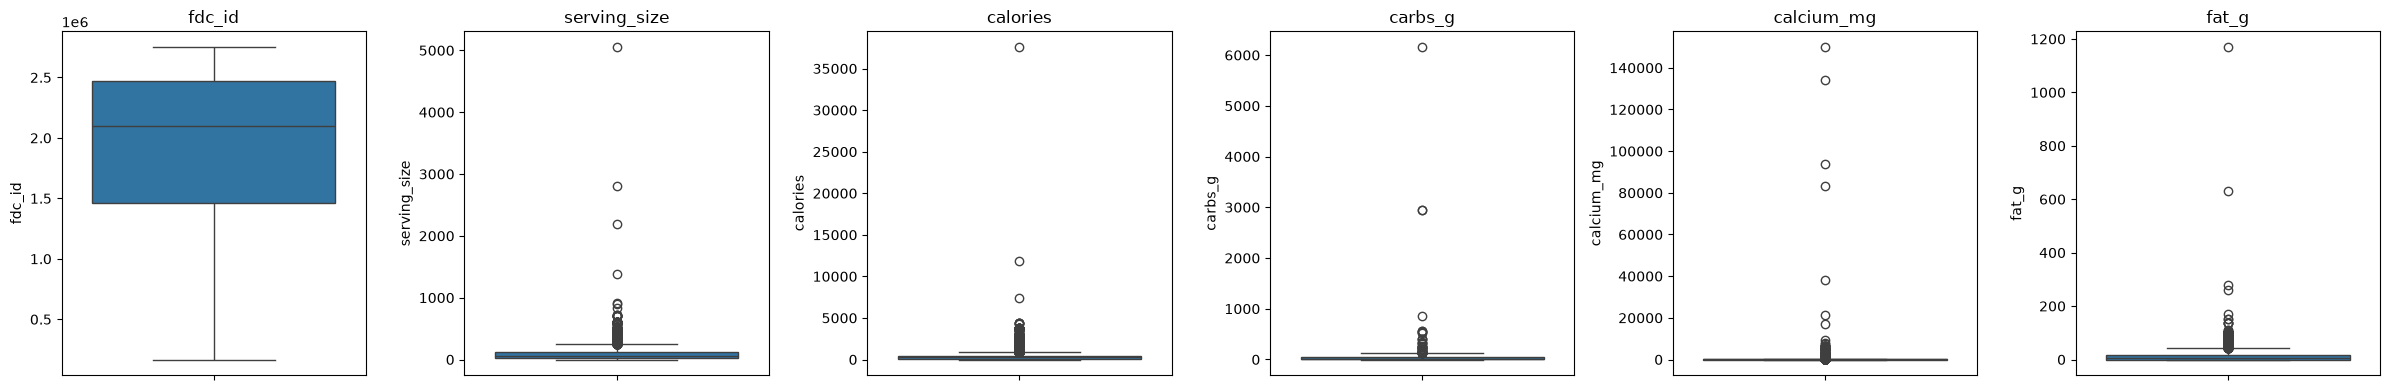

In [46]:
# Boxplots for a quick visual check (adjust column list once you know your real numeric columns)
cols_to_plot = list(numeric_cols_3)[:6]  # first 6 numeric columns as a sample
if cols_to_plot:
    fig, axes = plt.subplots(1, len(cols_to_plot), figsize=(4*len(cols_to_plot), 4))
    if len(cols_to_plot) == 1:
        axes = [axes]
    for ax, col in zip(axes, cols_to_plot):
        sns.boxplot(y=df3[col], ax=ax)
        ax.set_title(col)
    plt.tight_layout()
    plt.show()

## 9. Categorical Cardinality Check
How many unique values does each categorical column have? High-cardinality columns (e.g. IDs, free text) may need special handling or dropping.

In [47]:
categorical_cols_3 = df3.select_dtypes(include='str').columns
cardinality = df3[categorical_cols_3].nunique().sort_values(ascending=False)
cardinality

food_name            30900
ingredients          24696
brand_name            7174
brand_owner           5559
household_serving     4226
food_category          240
food_type                9
serving_unit             8
data_type                3
dtype: int64

## 10. Target Column Check — `Category`
Confirm the real target column — could be a food category/classification label. **Check carefully**: if most columns are free-text (ingredient lists, descriptions), this may fall under the excluded NLP/text category and should probably not be used.

## 11. Numerical vs Categorical Column Counts

In [48]:
numeric_cols_3 = df3.select_dtypes(include=np.number).columns
categorical_cols_3 = df3.select_dtypes(include='str').columns

print("Numerical columns:", len(numeric_cols_3))
print("Categorical columns:", len(categorical_cols_3))

print("\nNumerical:", list(numeric_cols_3))
print("\nCategorical:", list(categorical_cols_3))

Numerical columns: 15
Categorical columns: 9

Numerical: ['fdc_id', 'serving_size', 'calories', 'carbs_g', 'calcium_mg', 'fat_g', 'protein_g', 'saturated_fat_g', 'vitamin_c_mg', 'fiber_g', 'iron_mg', 'sodium_mg', 'sugar_g', 'cholesterol_mg', 'health_score']

Categorical: ['food_name', 'data_type', 'food_category', 'brand_owner', 'brand_name', 'ingredients', 'serving_unit', 'household_serving', 'food_type']


## 12. Memory Usage

In [49]:
df3.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fdc_id             40000 non-null  int64  
 1   food_name          40000 non-null  str    
 2   data_type          40000 non-null  str    
 3   food_category      39954 non-null  str    
 4   brand_owner        31383 non-null  str    
 5   brand_name         30254 non-null  str    
 6   ingredients        31656 non-null  str    
 7   serving_size       31842 non-null  float64
 8   serving_unit       31842 non-null  str    
 9   household_serving  30790 non-null  str    
 10  calories           39538 non-null  float64
 11  carbs_g            39411 non-null  float64
 12  calcium_mg         34215 non-null  float64
 13  fat_g              39713 non-null  float64
 14  protein_g          39747 non-null  float64
 15  saturated_fat_g    35014 non-null  float64
 16  vitamin_c_mg       22940 non-null

## 🧹 Additional Cleaning — Topic 2

In [50]:
# Fix target column name: the actual column is 'food_category', not 'Category'
target_col_3 = "food_category"
print(df3[target_col_3].value_counts(dropna=False).head(10))

food_category
Fruit & Vegetable Juice, Nectars & Fruit Drinks    1937
Cheese                                             1303
Candy                                              1185
Breads & Buns                                      1011
Chocolate                                           994
Beef Products                                       969
Milk                                                936
Wholesome Snacks                                    915
Vegetables and Vegetable Products                   902
Popcorn, Peanuts, Seeds & Related Snacks            850
Name: count, dtype: int64


In [51]:
# Normalize free-text / categorical columns: strip whitespace and lowercase
text_cols_3 = ['food_name', 'food_category', 'brand_owner', 'brand_name',
               'ingredients', 'serving_unit', 'household_serving', 'food_type']
for c in text_cols_3:
    if c in df3.columns:
        df3[c] = df3[c].astype('str').str.strip().str.lower()

df3[text_cols_3].head()

,food_name,food_category,brand_owner,brand_name,ingredients,serving_unit,household_serving,food_type
0,"abiyuch, raw",fruits and fruit juices,NaN,NaN,NaN,NaN,NaN,fruits
1,"acerola juice, raw",fruits and fruit juices,NaN,NaN,NaN,NaN,NaN,fruits
2,"acerola, (west indian cherry), raw",fruits and fruit juices,NaN,NaN,NaN,NaN,NaN,fruits
3,acorn stew (apache),american indian/alaska native foods,NaN,NaN,NaN,NaN,NaN,other
4,"agave, cooked (southwest)",american indian/alaska native foods,NaN,NaN,NaN,NaN,NaN,other


In [52]:
# Missing food_category can't be safely guessed -> label as 'unknown' rather than dropping rows
df3['food_category'] = df3['food_category'].fillna('unknown')

# Impute missing nutrition numeric values with the column median
nutrition_cols_3 = ['calories', 'carbs_g', 'calcium_mg', 'fat_g', 'protein_g',
                     'saturated_fat_g', 'vitamin_c_mg', 'fiber_g', 'iron_mg',
                     'sodium_mg', 'sugar_g', 'cholesterol_mg']
for c in nutrition_cols_3:
    if c in df3.columns and df3[c].isnull().any():
        df3[c] = df3[c].fillna(df3[c].median())

print("Remaining missing values:")
print(df3.isnull().sum().sort_values(ascending=False).head(10))

Remaining missing values:
brand_name           9746
household_serving    9210
brand_owner          8617
ingredients          8344
serving_unit         8158
serving_size         8158
food_category           0
data_type               0
fdc_id                  0
food_name               0
dtype: int64


In [53]:
# Remove near-duplicate food entries: same normalized food_name + brand_owner
dupe_mask = df3.duplicated(subset=['food_name', 'brand_owner'], keep='first')
print("Near-duplicate food entries removed:", dupe_mask.sum())
df3 = df3[~dupe_mask]

Near-duplicate food entries removed: 4327


## 13. Summary Checklist — Topic 2

Run the cell below to auto-generate the checklist from the cleaned `df3`.

In [54]:
from IPython.display import Markdown, display

missing_final_3 = df3.isnull().sum()
top_missing_3 = missing_final_3[missing_final_3 > 0].sort_values(ascending=False).head(5)
numeric_cols_final_3 = df3.select_dtypes(include=np.number).columns
categorical_cols_final_3 = df3.select_dtypes(include='str').columns
cardinality_final_3 = df3[categorical_cols_final_3].nunique().sort_values(ascending=False)
high_card_3 = cardinality_final_3[cardinality_final_3 > 50].index.tolist()

meets_req_3 = "✅ Yes" if (df3.shape[0] >= 15000 and df3.shape[1] >= 10) else "❌ No"
placeholder_txt_3 = ", ".join(f"{k} ({v})" for k, v in placeholder_summary_3.items()) if placeholder_summary_3 else "None found"
top_missing_txt_3 = ", ".join(top_missing_3.index.tolist()) if len(top_missing_3) else "None"
high_card_txt_3 = ", ".join(high_card_3) if high_card_3 else "None"

summary_md_3 = f'''
| Check | Result |
|---|---|
| Rows before cleaning | {rows_before_3:,} |
| Rows after removing duplicates | {df3.shape[0]:,} |
| Columns | {df3.shape[1]} |
| Meets 15k+ rows / 10+ columns requirement? | {meets_req_3} |
| Duplicate rows found | {dup_count_3:,} |
| Placeholder/sentinel missing values found? | {placeholder_txt_3} |
| Columns with most missing values | {top_missing_txt_3} |
| Numerical columns | {len(numeric_cols_final_3)} |
| Categorical columns | {len(categorical_cols_final_3)} |
| High-cardinality categorical columns (>50 unique) | {high_card_txt_3} |
'''
display(Markdown(summary_md_3))



| Check | Result |
|---|---|
| Rows before cleaning | 40,000 |
| Rows after removing duplicates | 35,673 |
| Columns | 24 |
| Meets 15k+ rows / 10+ columns requirement? | ✅ Yes |
| Duplicate rows found | 0 |
| Placeholder/sentinel missing values found? | None found |
| Columns with most missing values | brand_name, household_serving, brand_owner, ingredients, serving_size |
| Numerical columns | 15 |
| Categorical columns | 9 |
| High-cardinality categorical columns (>50 unique) | food_name, ingredients, brand_name, brand_owner, household_serving, food_category |


---
# 📱 Topic 3: Customer Churn Prediction (1M rows)

**File:** `Customer_Churn_1M.csv` &nbsp;|&nbsp; **Target column (placeholder):** `Churn`



### 📋 Topic 3 — Required Write-up

**Problem Statement**
Subscription businesses lose recurring revenue when customers churn, and by the time a customer cancels it's too late to intervene - the company needs to know who is at risk *before* they leave.

**Goals**
Build a binary classifier that predicts customer `churn` from account, billing, and usage/support features, so retention teams can target at-risk customers proactively.

**Approach**
1. Clean and inspect the raw customer data (this notebook, 1M rows).
2. Handle missing values in billing/usage/support columns and fix data types (dates, numeric charges).
3. Train baseline Logistic Regression, then Random Forest / XGBoost / LightGBM.
4. Evaluate with ROC-AUC and recall on the churn class, checking for class imbalance.

**Data Source(s)**
Customer Churn Prediction Dataset (Kaggle) - 1,000,000 telecom/subscription customer records with demographic, billing, contract, and service-usage columns.

**Data Info (basic EDA)**
See sections 1-13 below for shape, dtypes, missingness, duplicates, outliers, and target distribution.

⚠️ Note: the placeholder target above was listed as `Churn`, but the real column in this dataset is lowercase **`churn`** - this is what caused the `KeyError: 'Churn'` in Section 10 above. Fixed in Section 14 below.


## 1. Load Data & Raw Shape

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# NOTE: update filename/path to match your downloaded file
df4 = pd.read_csv("./data/Customer_Churn_1M.csv")

print("Rows and Columns (before cleaning):", df4.shape)

rows_before_4 = df4.shape[0]  # captured for the summary checklist below


Rows and Columns (before cleaning): (1000000, 32)


In [56]:
df4.head()

,customer_id,signup_date,age,gender,annual_income,education,marital_status,dependents,tenure,contract,...,has_streaming_tv,has_streaming_movies,customer_satisfaction,num_complaints,num_service_calls,late_payments,avg_monthly_gb,days_since_last_interaction,credit_score,churn
0,CUST0000000001,2022-12-12 12:53:58.199463,43,Female,55085.25,college,married,1,2,two_year,...,1,1,9.0,0.0,0,0,109.63,16,NaN,0
1,CUST0000000002,2022-01-13 12:53:58.199973,18,Male,60786.11,master,married,1,22,one_year,...,0,1,7.0,0.0,3,1,63.25,134,585.0,0
2,CUST0000000003,2023-09-04 12:53:58.199985,38,Female,73184.32,high_school,widowed,0,3,two_year,...,1,0,6.0,1.0,1,0,47.77,11,632.0,0
3,CUST0000000004,2022-06-27 12:53:58.199992,44,Male,40923.78,high_school,married,1,6,two_year,...,0,1,5.0,2.0,2,1,50.82,6,569.0,0
4,CUST0000000005,2022-12-08 12:53:58.199999,45,Female,36400.94,bachelor,single,0,9,two_year,...,0,1,8.0,1.0,1,0,16.74,18,657.0,0


### 📖 Data Dictionary — Topic 3 (Customer Churn, `df4`)

| Column | Type | Description |
|---|---|---|
| `customer_id` | string | Unique customer identifier (not predictive — exclude from modeling features) |
| `signup_date` | datetime | Date the customer signed up |
| `churn` | int/bool | **Target.** 1/Yes = customer churned, 0/No = retained |
| `annual_income` | float | Customer's annual income |
| `customer_satisfaction` | float | Satisfaction score (survey-based) |
| `avg_monthly_gb` | float | Average monthly data usage |
| `credit_score` | float | Customer credit score |
| `totalcharges` | float | Total amount billed to date |
| `num_complaints` | int | Number of support complaints logged |

*Note: internal variable name for this dataframe stays `df4` (matches its original position as Topic 4), even though it's now the notebook's 3rd topic. Additional columns (e.g. contract type, tenure, monthly charges) may exist in the real file — confirm and extend this table once loaded.*


## 2. Columns & Data Types

In [57]:
df4.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   customer_id                  1000000 non-null  str    
 1   signup_date                  1000000 non-null  str    
 2   age                          1000000 non-null  int64  
 3   gender                       1000000 non-null  str    
 4   annual_income                970041 non-null   float64
 5   education                    1000000 non-null  str    
 6   marital_status               1000000 non-null  str    
 7   dependents                   1000000 non-null  int64  
 8   tenure                       1000000 non-null  int64  
 9   contract                     1000000 non-null  str    
 10  payment_method               1000000 non-null  str    
 11  paperless_billing            1000000 non-null  str    
 12  senior_citizen               1000000 non-null  int64  

## 3. Descriptive Statistics (`describe()`)
Numerical summary first, then categorical summary.

In [58]:
# Numerical columns summary
df4.describe()

,age,annual_income,dependents,tenure,senior_citizen,monthlycharges,totalcharges,num_services,has_phone_service,has_internet_service,...,has_streaming_tv,has_streaming_movies,customer_satisfaction,num_complaints,num_service_calls,late_payments,avg_monthly_gb,days_since_last_interaction,credit_score,churn
count,1000000.000000,970041.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,...,1000000.00000,1000000.000000,980079.000000,970094.000000,1000000.000000,1000000.000000,949988.000000,1000000.000000,959605.000000,1000000.000000
mean,44.724603,58788.311936,0.799831,22.381923,0.199511,86.443701,1837.321438,2.563721,0.769551,0.849742,...,0.59999,0.549086,6.159110,0.701667,1.760248,0.400969,39.095179,44.494191,678.562134,0.099227
std,14.479468,37137.433079,0.893654,20.073341,0.399633,27.592430,1803.721634,1.412330,0.421120,0.357324,...,0.48990,0.497585,2.328287,0.838148,1.485677,0.633289,43.852564,44.922587,87.642951,0.298967
min,18.000000,20000.000000,0.000000,1.000000,0.000000,20.000000,16.300000,1.000000,0.000000,0.000000,...,0.00000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,300.000000,0.000000
25%,34.000000,32712.560000,0.000000,6.000000,0.000000,70.490000,484.530000,1.000000,1.000000,1.000000,...,0.00000,0.000000,4.000000,0.000000,1.000000,0.000000,12.840000,12.000000,619.000000,0.000000
50%,44.000000,48954.600000,1.000000,16.000000,0.000000,85.480000,1249.750000,2.000000,1.000000,1.000000,...,1.00000,1.000000,7.000000,1.000000,1.000000,0.000000,27.770000,31.000000,680.000000,0.000000
75%,55.000000,73475.130000,1.000000,33.000000,0.000000,100.680000,2617.660000,3.000000,1.000000,1.000000,...,1.00000,1.000000,8.000000,1.000000,3.000000,1.000000,51.230000,62.000000,740.000000,0.000000
max,90.000000,250000.000000,5.000000,72.000000,1.000000,854.956730,16252.861508,6.000000,1.000000,1.000000,...,1.00000,1.000000,9.000000,7.000000,12.000000,5.000000,557.824023,365.000000,850.000000,1.000000


In [59]:
# Categorical / object columns summary
df4.describe(include='str')

,customer_id,signup_date,gender,education,marital_status,contract,payment_method,paperless_billing
count,1000000,1000000,1000000,1000000,1000000,1000000,1000000,1000000
unique,1000000,1000000,3,5,4,3,4,2
top,CUST0000000001,2022-12-12 12:53:58.199463,Male,bachelor,married,one_year,credit_card,Yes
freq,1,1,490166,300324,450115,550468,349706,749880


## 4. Missing Values

In [60]:
missing = df4.isnull().sum()
missing_percentage = (missing / len(df4)) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percentage
})

missing_table.sort_values(by="Missing Values", ascending=False).head(20)

,Missing Values,Percentage
avg_monthly_gb,50012,5.0012
credit_score,40395,4.0395
annual_income,29959,2.9959
num_complaints,29906,2.9906
customer_satisfaction,19921,1.9921
customer_id,0,0.0000
age,0,0.0000
signup_date,0,0.0000
tenure,0,0.0000
contract,0,0.0000


**Plan for missing values** *(fill in after seeing real output)*:
- High missing % (e.g. >40-50%) → consider dropping the column
- Low missing % → impute (median for numeric / mode for categorical) or drop rows
- Document reasoning per column here once known.

## 5. Duplicate Rows

In [61]:
dup_count_4 = df4.duplicated().sum()
print("Duplicate rows:", dup_count_4)

Duplicate rows: 0


In [62]:
df4 = df4.drop_duplicates()
print("Shape after removing duplicates:", df4.shape)

Shape after removing duplicates: (1000000, 32)


## 6. Column Integrity Check
Confirm no columns were lost unintentionally.

In [63]:
original_columns_4 = df4.columns
print("Original column count:", len(original_columns_4))

Original column count: 32


In [64]:
print("Current column count:", len(df4.columns))

Current column count: 32


## 7. Sentinel / Placeholder Missing Values
Some datasets hide missing data behind values like `-1`, `0` (when it shouldn't be), `'Unknown'`, `'N/A'`, `'?'`, or empty strings — these won't show up in `isnull()`. Worth checking before EDA.

In [65]:
# Check for common placeholder strings in object columns
placeholder_values = ['?', 'Unknown', 'unknown', 'N/A', 'n/a', 'NA', '', ' ', 'None', 'null']

placeholder_summary_4 = {}
for col in df4.select_dtypes(include='str').columns:
    found = df4[col].isin(placeholder_values).sum()
    if found > 0:
        placeholder_summary_4[col] = int(found)
        print(f"{col}: {found} placeholder-like values")

if not placeholder_summary_4:
    print("No placeholder-style missing values found.")


No placeholder-style missing values found.


## 8. Outlier Detection (IQR Method)
Flags numeric columns with potential outliers using the 1.5×IQR rule.

In [66]:
numeric_cols_4 = df4.select_dtypes(include=np.number).columns
outlier_summary = {}

for col in numeric_cols_4:
    Q1 = df4[col].quantile(0.25)
    Q3 = df4[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df4[col] < lower) | (df4[col] > upper)).sum()
    if n_outliers > 0:
        outlier_summary[col] = n_outliers

pd.DataFrame.from_dict(outlier_summary, orient='index', columns=['Outlier Count']).sort_values('Outlier Count', ascending=False)

,Outlier Count
has_phone_service,230449
senior_citizen,199511
has_internet_service,150258
churn,99227
avg_monthly_gb,56428
dependents,47406
days_since_last_interaction,47040
totalcharges,45654
annual_income,44871
num_complaints,33220


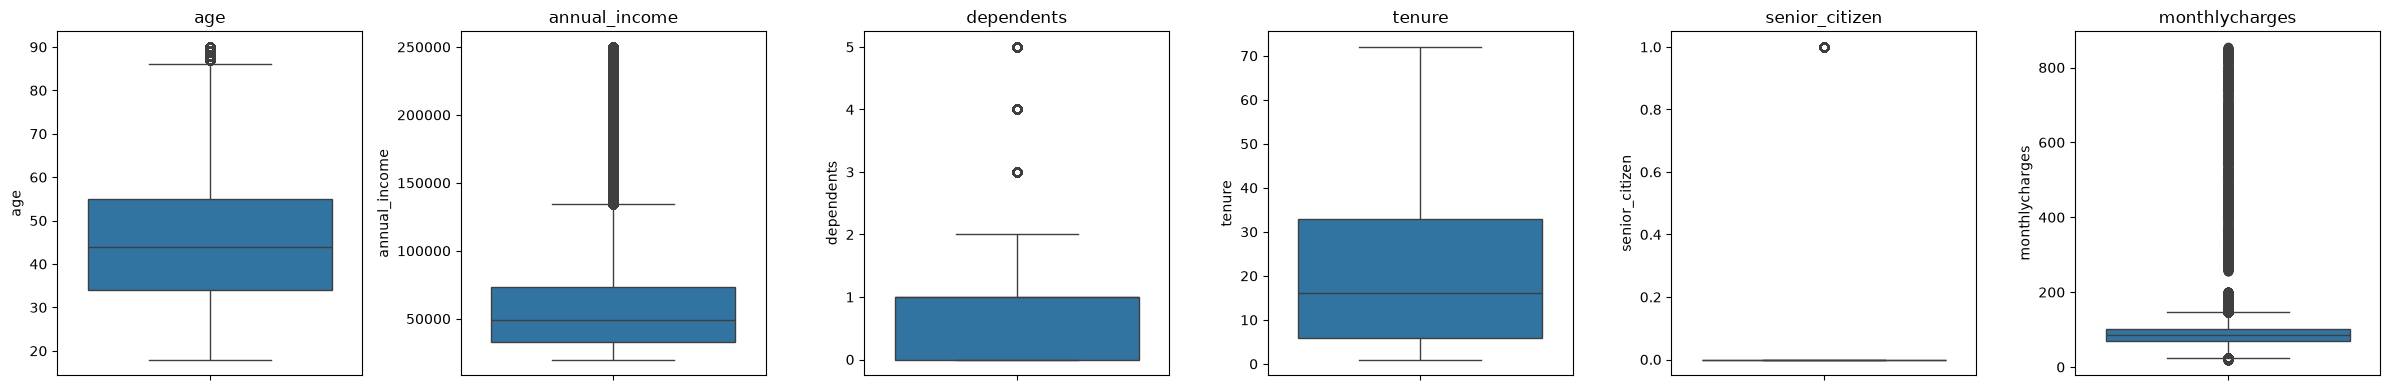

In [67]:
# Boxplots for a quick visual check (adjust column list once you know your real numeric columns)
cols_to_plot = list(numeric_cols_4)[:6]  # first 6 numeric columns as a sample
if cols_to_plot:
    fig, axes = plt.subplots(1, len(cols_to_plot), figsize=(4*len(cols_to_plot), 4))
    if len(cols_to_plot) == 1:
        axes = [axes]
    for ax, col in zip(axes, cols_to_plot):
        sns.boxplot(y=df4[col], ax=ax)
        ax.set_title(col)
    plt.tight_layout()
    plt.show()

## 9. Categorical Cardinality Check
How many unique values does each categorical column have? High-cardinality columns (e.g. IDs, free text) may need special handling or dropping.

In [68]:
categorical_cols_4 = df4.select_dtypes(include='str').columns
cardinality = df4[categorical_cols_4].nunique().sort_values(ascending=False)
cardinality

customer_id          1000000
signup_date          1000000
education                  5
marital_status             4
payment_method             4
gender                     3
contract                   3
paperless_billing          2
dtype: int64

## 10. Target Column Check — `Churn`
`Churn` is typically binary (Yes/No or 1/0) → this is a **classification** problem. Check class balance carefully — churn is often imbalanced (fewer churners than non-churners).

In [69]:
target_col_4 = "Churn"  # <-- update to the real column name once confirmed

df4[target_col_4].value_counts()

KeyError: 'Churn'

In [ ]:
plt.figure(figsize=(6,4))
if df4[target_col_4].dtype == 'str' or df4[target_col_4].nunique() < 20:
    sns.countplot(x=target_col_4, data=df4)
else:
    sns.histplot(df4[target_col_4], kde=True)
plt.title(f"Distribution of {target_col_4}")
plt.show()

## 11. Numerical vs Categorical Column Counts

In [ ]:
numeric_cols_4 = df4.select_dtypes(include=np.number).columns
categorical_cols_4 = df4.select_dtypes(include='str').columns

print("Numerical columns:", len(numeric_cols_4))
print("Categorical columns:", len(categorical_cols_4))

print("\nNumerical:", list(numeric_cols_4))
print("\nCategorical:", list(categorical_cols_4))

## 12. Memory Usage

In [ ]:
df4.info(memory_usage='deep')

## 🧹 Additional Cleaning — Topic 3

In [ ]:
# Fix target column name bug: the actual column is lowercase 'churn'
target_col_4 = "churn"
print(df4[target_col_4].value_counts(normalize=True))

In [ ]:
# Standardize column names (already mostly lowercase, but strip whitespace just in case)
df4.columns = [c.strip().lower() for c in df4.columns]

In [ ]:
# Fix data types: signup_date -> datetime, totalcharges -> numeric (coerce blanks/bad strings)
df4['signup_date'] = pd.to_datetime(df4['signup_date'], errors='coerce')
df4['totalcharges'] = pd.to_numeric(df4['totalcharges'], errors='coerce')

print("Rows with unparseable signup_date:", df4['signup_date'].isnull().sum())
print("Rows with unparseable totalcharges:", df4['totalcharges'].isnull().sum())

In [ ]:
# Impute missing values with sensible defaults per column type
impute_median_cols = ['annual_income', 'customer_satisfaction', 'avg_monthly_gb',
                       'credit_score', 'totalcharges']
impute_zero_cols = ['num_complaints']

for c in impute_median_cols:
    if c in df4.columns and df4[c].isnull().any():
        df4[c] = df4[c].fillna(df4[c].median())

for c in impute_zero_cols:
    if c in df4.columns and df4[c].isnull().any():
        df4[c] = df4[c].fillna(0)

print("Remaining missing values:")
print(df4.isnull().sum().sort_values(ascending=False).head(10))

In [ ]:
# customer_id is a unique identifier, not a predictive feature -> keep for reference
# but exclude it (and signup_date, once tenure is derived) from the modeling feature set later
print("Unique customer_id values:", df4['customer_id'].nunique(), "/", len(df4))

## 13. Summary Checklist — Topic 3

Run the cell below to auto-generate the checklist from the cleaned `df4`.

In [ ]:
from IPython.display import Markdown, display

missing_final_4 = df4.isnull().sum()
top_missing_4 = missing_final_4[missing_final_4 > 0].sort_values(ascending=False).head(5)
numeric_cols_final_4 = df4.select_dtypes(include=np.number).columns
categorical_cols_final_4 = df4.select_dtypes(include='str').columns
cardinality_final_4 = df4[categorical_cols_final_4].nunique().sort_values(ascending=False)
high_card_4 = cardinality_final_4[cardinality_final_4 > 50].index.tolist()

meets_req_4 = "✅ Yes" if (df4.shape[0] >= 15000 and df4.shape[1] >= 10) else "❌ No"
placeholder_txt_4 = ", ".join(f"{k} ({v})" for k, v in placeholder_summary_4.items()) if placeholder_summary_4 else "None found"
top_missing_txt_4 = ", ".join(top_missing_4.index.tolist()) if len(top_missing_4) else "None"
high_card_txt_4 = ", ".join(high_card_4) if high_card_4 else "None"

summary_md_4 = f'''
| Check | Result |
|---|---|
| Rows before cleaning | {rows_before_4:,} |
| Rows after removing duplicates | {df4.shape[0]:,} |
| Columns | {df4.shape[1]} |
| Meets 15k+ rows / 10+ columns requirement? | {meets_req_4} |
| Duplicate rows found | {dup_count_4:,} |
| Placeholder/sentinel missing values found? | {placeholder_txt_4} |
| Columns with most missing values | {top_missing_txt_4} |
| Numerical columns | {len(numeric_cols_final_4)} |
| Categorical columns | {len(categorical_cols_final_4)} |
| High-cardinality categorical columns (>50 unique) | {high_card_txt_4} |
'''
display(Markdown(summary_md_4))


---
# 📊 Cross-Topic Comparison

Auto-generated from the three cleaned dataframes above. Use this table to help decide on the final topic for the Lightning Talk.


In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "🚗 Accidents": {
        "Rows (after cleaning)": df1.shape[0],
        "Columns": df1.shape[1],
        "Meets 15k+/10+ requirement?": meets_req_1,
        "Target column": "Severity",
        "Classification or Regression?": "Classification",
        "Target balanced?": "No (highly imbalanced per instructor review)",
        "% missing (worst column)": f"{missing_final_1.max() / len(df1) * 100:.1f}%" if missing_final_1.max() > 0 else "0%",
    },
    "🍎 Food/Nutrition": {
        "Rows (after cleaning)": df3.shape[0],
        "Columns": df3.shape[1],
        "Meets 15k+/10+ requirement?": meets_req_3,
        "Target column": "food_category",
        "Classification or Regression?": "Classification",
        "Target balanced?": df3['food_category'].value_counts(normalize=True).round(3).to_dict(),
        "% missing (worst column)": f"{missing_final_3.max() / len(df3) * 100:.1f}%" if missing_final_3.max() > 0 else "0%",
    },
    "📱 Churn": {
        "Rows (after cleaning)": df4.shape[0],
        "Columns": df4.shape[1],
        "Meets 15k+/10+ requirement?": meets_req_4,
        "Target column": "churn",
        "Classification or Regression?": "Classification",
        "Target balanced?": "No (imbalanced & synthetic per instructor review)",
        "% missing (worst column)": f"{missing_final_4.max() / len(df4) * 100:.1f}%" if missing_final_4.max() > 0 else "0%",
    },
})

comparison
